<a href="https://colab.research.google.com/github/eacharan21/Outlier-Treatment-ML-Study/blob/main/Outlier_treatment_on_Weather_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries and Data

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from google.colab import files

In [ ]:
df=pd.read_excel("/content/drive/MyDrive/VIT/Weather Analysis/Weather Data Nasa.xlsx")
df

,Date,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN
0,1984-01-01,27.95,17.44,73.56,0.00,4.08,10.77
1,1984-01-02,27.74,18.24,77.27,0.09,2.50,14.43
2,1984-01-03,26.90,18.09,76.88,0.35,2.05,10.54
3,1984-01-04,27.93,16.72,74.57,0.01,2.47,14.72
4,1984-01-05,28.76,17.18,72.62,0.00,2.38,16.39
...,...,...,...,...,...,...,...
15184,2025-07-28,29.81,21.18,73.95,0.15,5.34,15.02
15185,2025-07-29,30.01,21.63,72.05,0.36,5.48,15.05
15186,2025-07-30,29.98,22.20,75.19,1.88,4.45,11.42
15187,2025-07-31,32.11,22.35,73.29,0.40,3.65,18.24


## Preprocessing


In [ ]:
df.rename(columns={
    'T2M_MAX': 'Max_temp',
    'T2M_MIN': 'Min_temp',
    'RH2M': 'Humidity',
    'PRECTOTCORR': 'Rain',
    'WS2M': 'Wind_speed',
    'ALLSKY_SFC_SW_DWN': 'Radiation'},inplace=True)
df.head()

,Date,Max_temp,Min_temp,Humidity,Rain,Wind_speed,Radiation
0,1984-01-01,27.95,17.44,73.56,0.00,4.08,10.77
1,1984-01-02,27.74,18.24,77.27,0.09,2.50,14.43
2,1984-01-03,26.90,18.09,76.88,0.35,2.05,10.54
3,1984-01-04,27.93,16.72,74.57,0.01,2.47,14.72
4,1984-01-05,28.76,17.18,72.62,0.00,2.38,16.39


In [ ]:
df.isna().sum()

,0
Date,0
Max_temp,0
Min_temp,0
Humidity,0
Rain,0
Wind_speed,0
Radiation,0


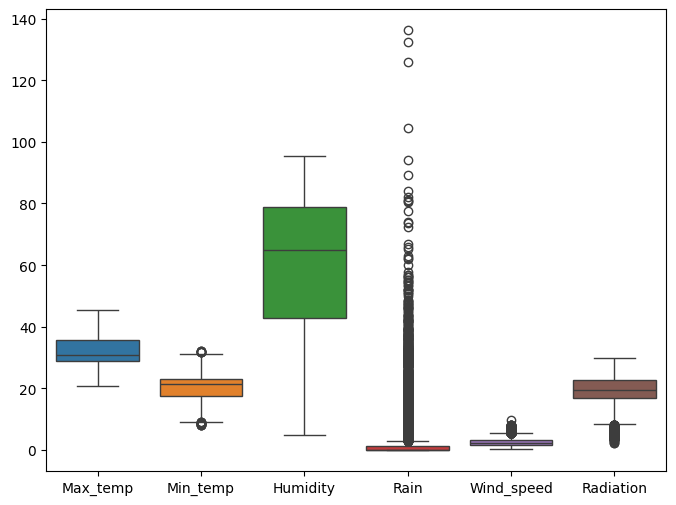

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.show()

In [ ]:
numerical_cols=df.select_dtypes(include=['float64','int64']).columns
for col in numerical_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    print(f"Column: {col}")
    print(f"  Lower Bound : {lower_bound}")
    print(f"  Upper Bound : {upper_bound}")
    outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
    print(f"  Number of outliers: {len(outliers)}")
    print()

Column: Max_temp
  Lower Bound : 18.434999999999995
  Upper Bound : 46.23500000000001
  Number of outliers: 0

Column: Min_temp
  Lower Bound : 9.089999999999996
  Upper Bound : 31.490000000000002
  Number of outliers: 21

Column: Humidity
  Lower Bound : -11.160000000000004
  Upper Bound : 132.92000000000002
  Number of outliers: 0

Column: Rain
  Lower Bound : -1.8599999999999999
  Upper Bound : 3.0999999999999996
  Number of outliers: 2540

Column: Wind_speed
  Lower Bound : -0.595
  Upper Bound : 5.525
  Number of outliers: 391

Column: Radiation
  Lower Bound : 8.314999999999998
  Upper Bound : 31.155
  Number of outliers: 244



In [ ]:
#BOX-COX Transformation
lambdas = {}
for col in ["Max_temp", "Min_temp", "Humidity", "Rain", "Wind_speed", "Radiation"]:
    shifted=df[col]+1
    transformed,fitted_lambda=boxcox(shifted)
    df[col]=transformed
    lambdas[col]=fitted_lambda
df.head()

,Date,Max_temp,Min_temp,Humidity,Rain,Wind_speed,Radiation
0,1984-01-01,0.574438,52.149435,256.143782,0.000000,0.985025,39.852312
1,1984-01-02,0.574416,55.624026,273.652729,0.081231,0.844193,63.846405
2,1984-01-03,0.574327,54.966931,271.797915,0.245522,0.782490,38.502381
3,1984-01-04,0.574436,49.086048,260.880161,0.009882,0.840500,65.944008
4,1984-01-05,0.574516,51.036179,251.756242,0.000000,0.829092,78.565305


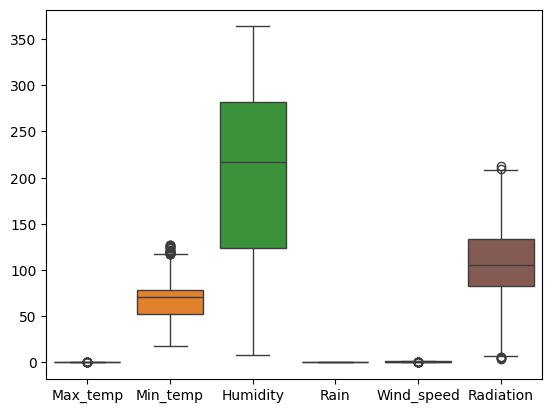

In [ ]:
sns.boxplot(data=df)
plt.show()

In [ ]:
df

,Date,Max_temp,Min_temp,Humidity,Rain,Wind_speed,Radiation
0,1984-01-01,0.574438,52.149435,256.143782,0.000000,0.985025,39.852312
1,1984-01-02,0.574416,55.624026,273.652729,0.081231,0.844193,63.846405
2,1984-01-03,0.574327,54.966931,271.797915,0.245522,0.782490,38.502381
3,1984-01-04,0.574436,49.086048,260.880161,0.009882,0.840500,65.944008
4,1984-01-05,0.574516,51.036179,251.756242,0.000000,0.829092,78.565305
...,...,...,...,...,...,...,...
15184,2025-07-28,0.574609,69.009586,257.969977,0.127060,1.053389,68.143482
15185,2025-07-29,0.574626,71.141065,249.105444,0.250366,1.059589,68.365076
15186,2025-07-30,0.574623,73.871502,263.798901,0.555007,1.007839,43.770503
15187,2025-07-31,0.574785,74.595667,254.881494,0.268921,0.954736,93.602947


In [ ]:
df['Year']=pd.to_datetime(df['Date']).dt.year
df['Month']=pd.to_datetime(df['Date']).dt.month_name()
df['Day']=pd.to_datetime(df['Date']).dt.day_name()

## Exploratory Data Analysis

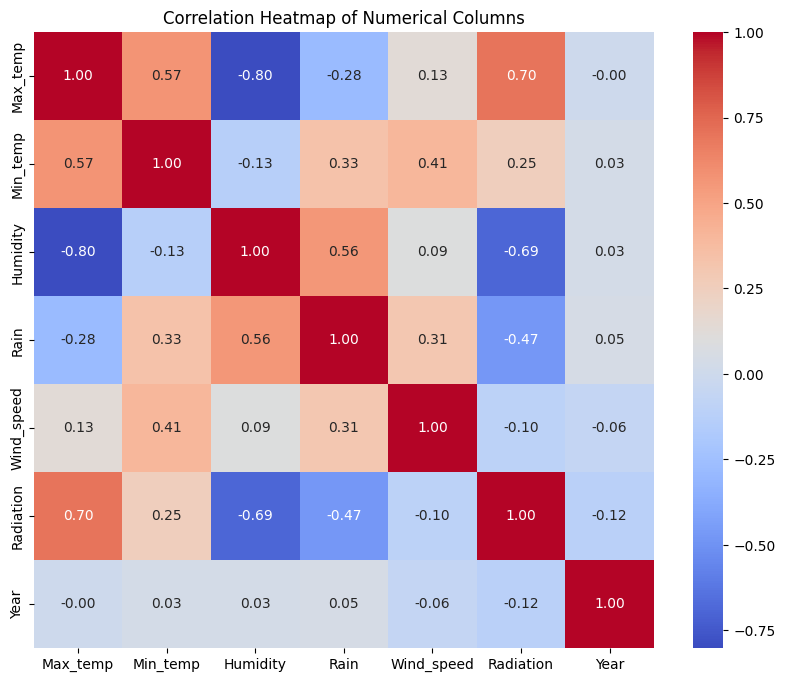

In [ ]:
correlation_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

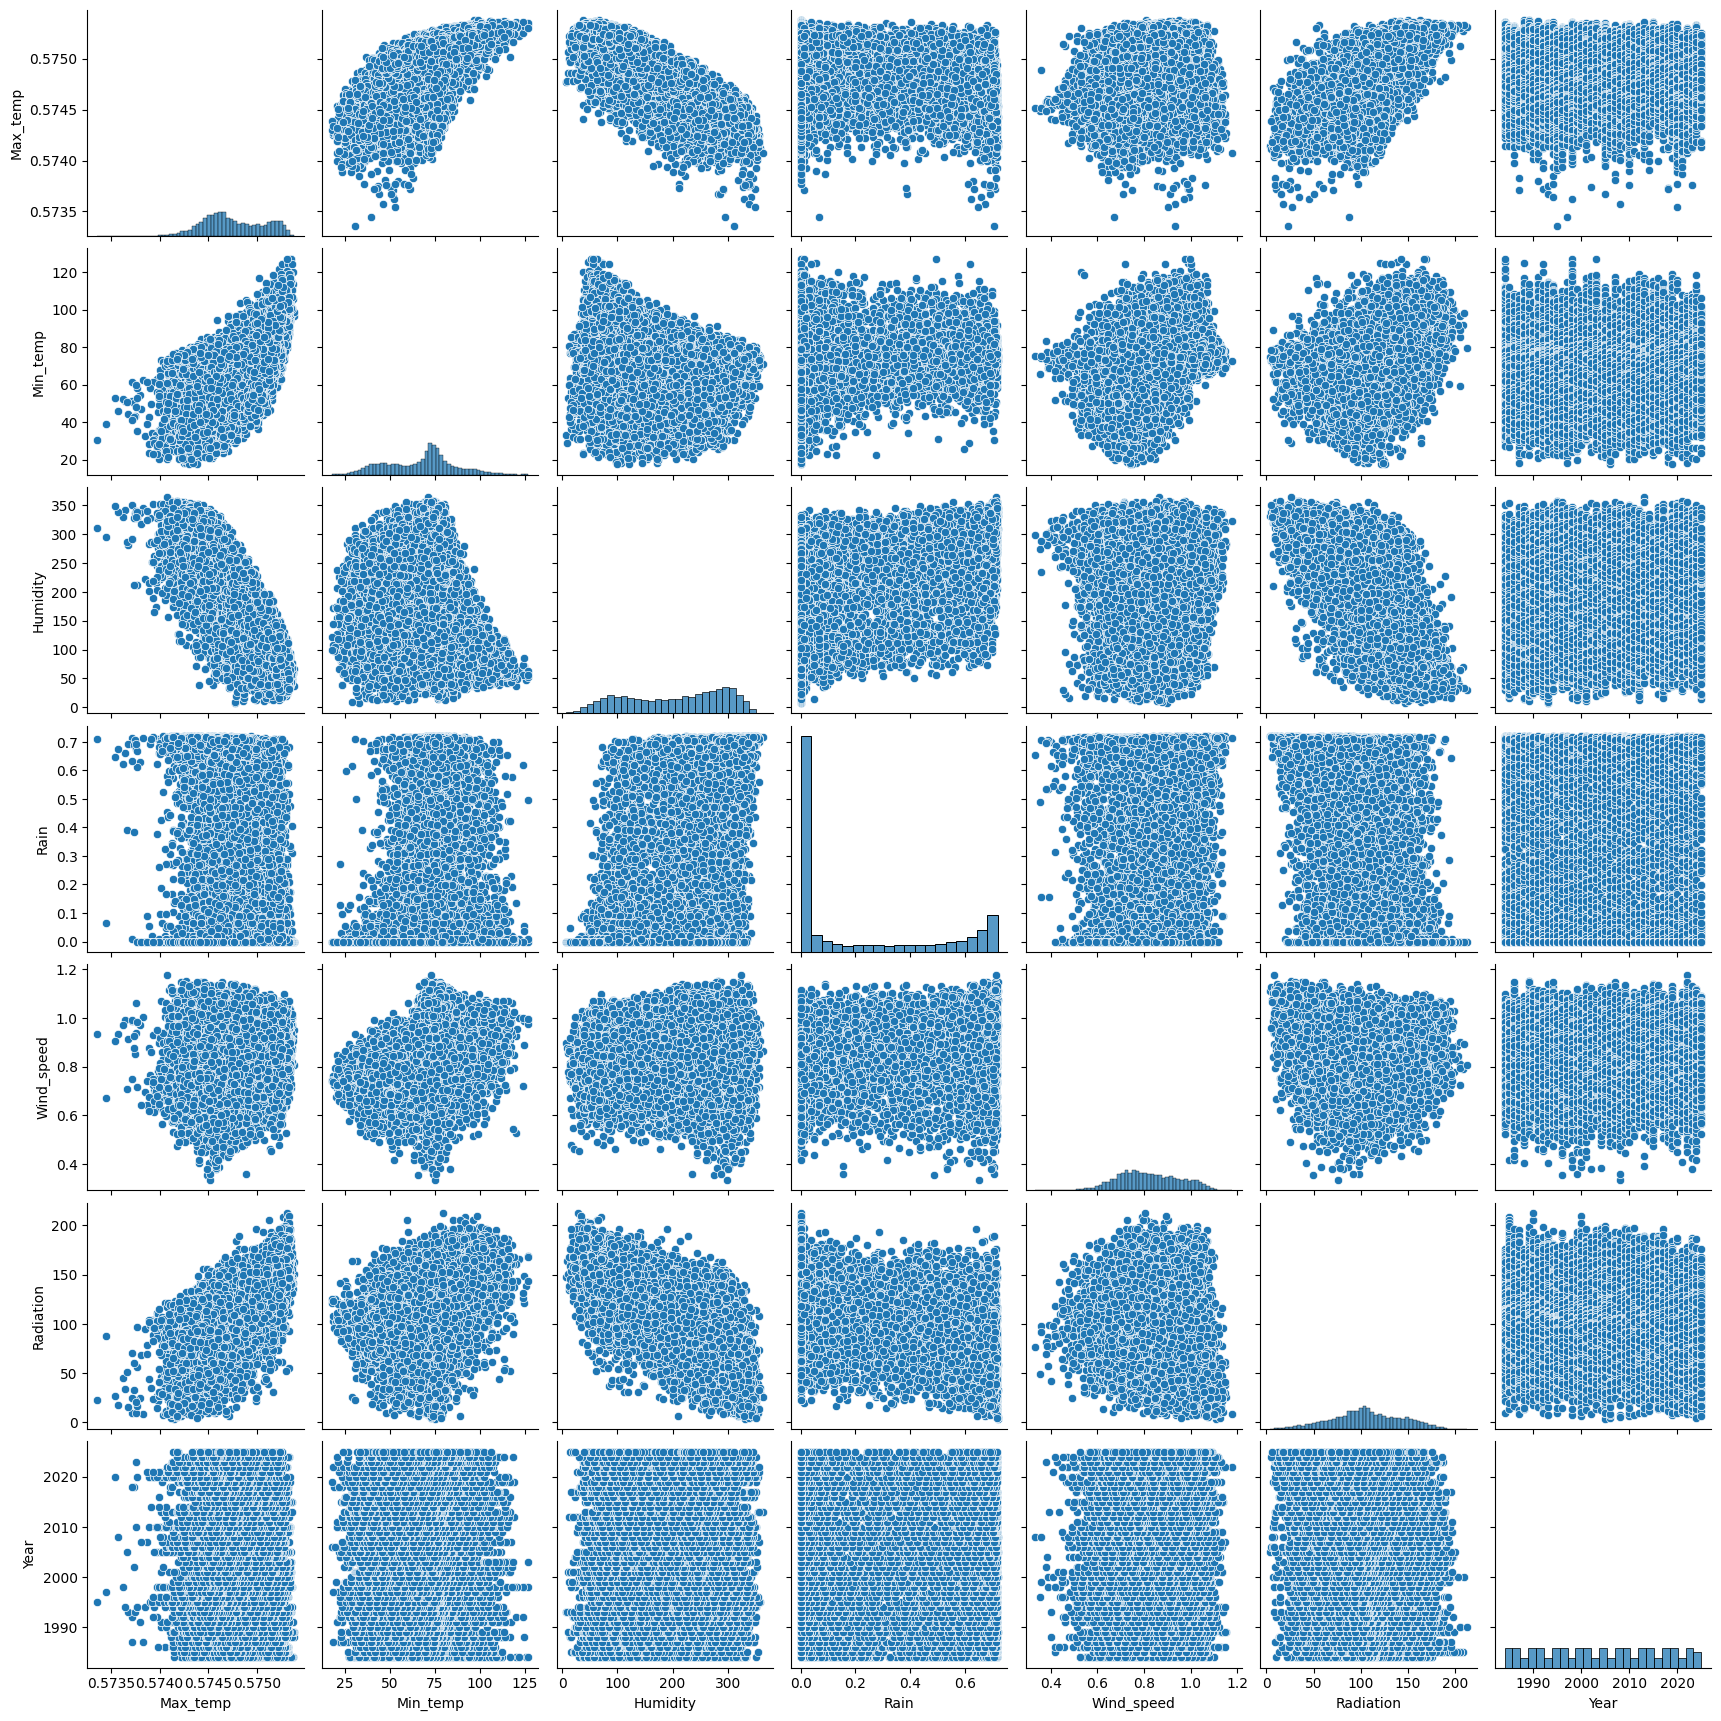

In [ ]:
sns.pairplot(df)
plt.show()

### Exploratory Data Analysis based on Rain

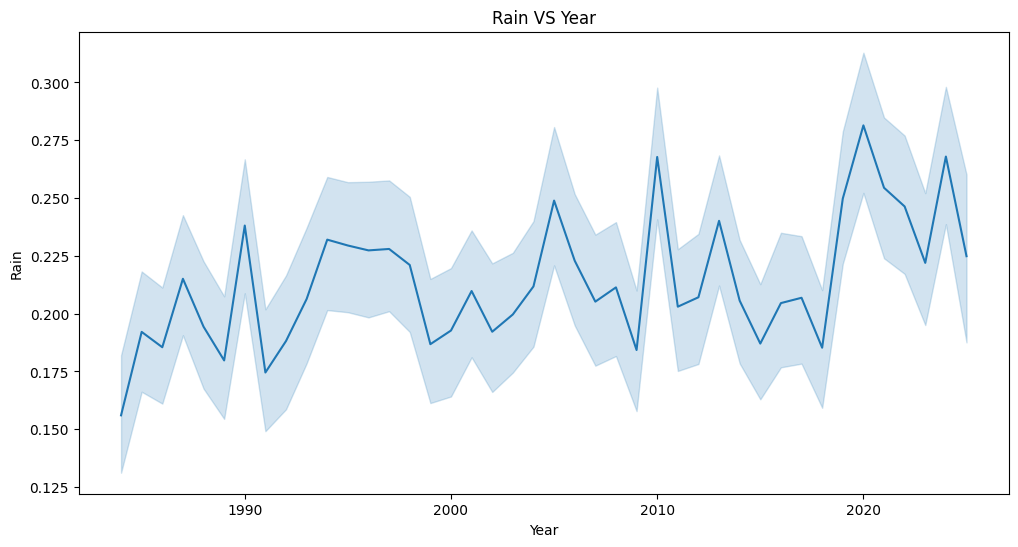

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year',y='Rain')
plt.title('Rain VS Year')
plt.xlabel('Year')
plt.ylabel('Rain')
plt.show()

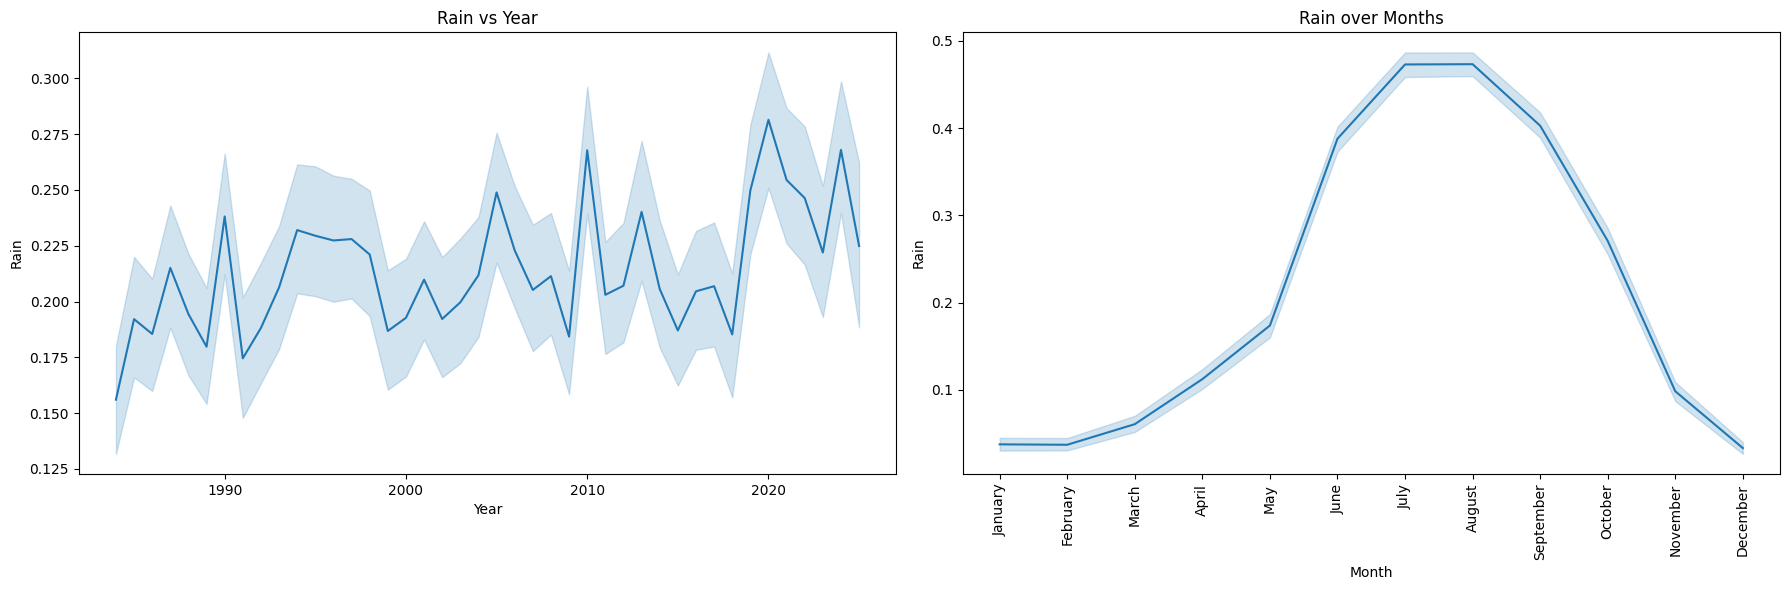

In [ ]:


# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Rain vs Year
sns.lineplot(data=df, x='Year', y='Rain', ax=axes[0])
axes[0].set_title('Rain vs Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rain')

# Plot 2: Rain vs Month
sns.lineplot(data=df, x='Month', y='Rain', ax=axes[1])
axes[1].set_title('Rain over Months')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Rain')
axes[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()


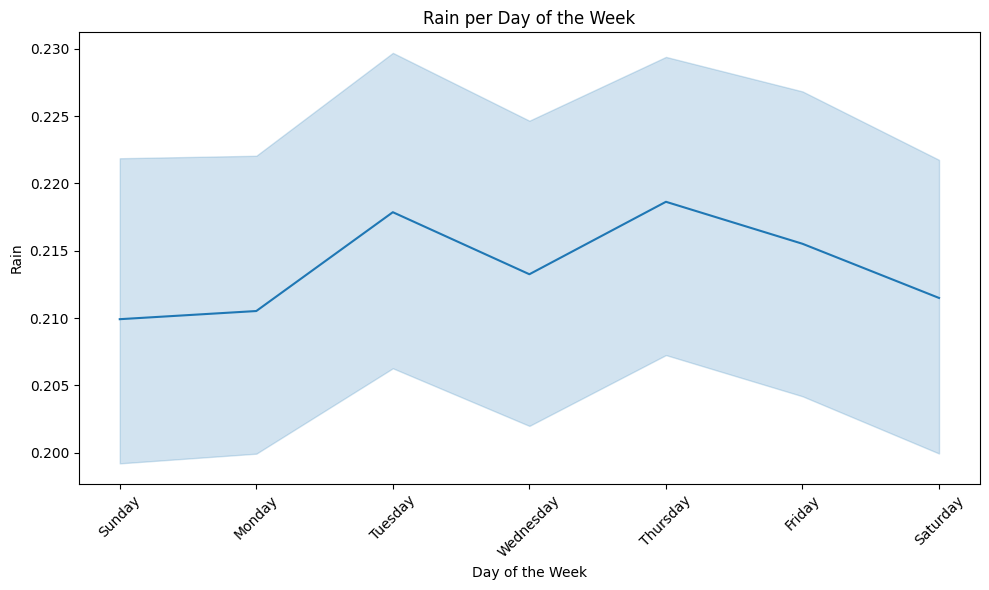

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Day',y='Rain')
plt.title('Rain per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Rain')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

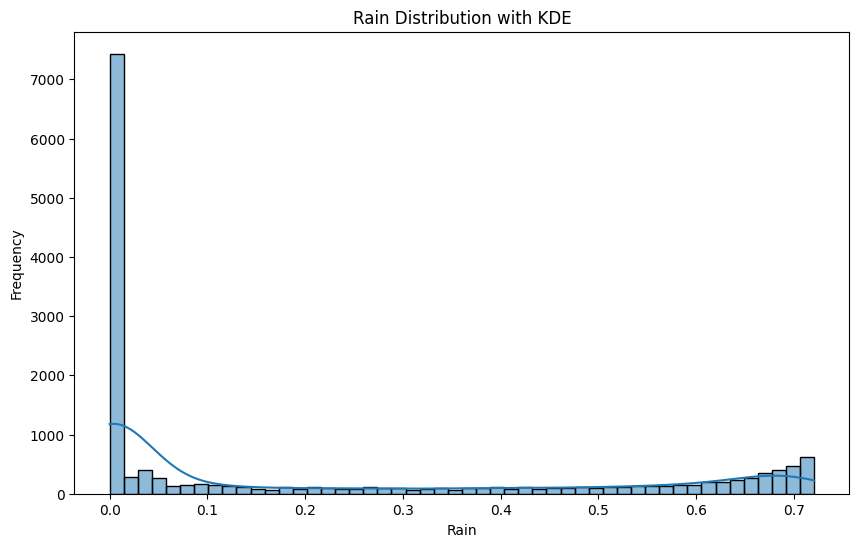

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['Rain'], bins=50, kde=True)
plt.title('Rain Distribution with KDE')
plt.xlabel('Rain')
plt.ylabel('Frequency')
plt.show()
